In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [11]:
from src.config import get_path, get_sample_window

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_P2 = get_path('data_phase2')
RES_P2 = get_path('results_phase2')
FIG_DIR = RES_P2 / 'figures'
TAB_DIR = RES_P2 / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

d = np.load(DATA_P2 / 'phase2_densities.npz')
R = d['R_grid']
p_enh = d['p_almeida']
p_van = d['p_vanilla']
p_kde = d['p_kde']
q_cme = d['q_cme']
q_der = d['q_der']

# Load summary (three estimators x two venues)
summary = pd.read_csv(TAB_DIR / 'ep_decomposition_summary.csv')
print("--- EP Decomposition Summary ---")
print(summary.to_string(index=False))

--- EP Decomposition Summary ---
venue estimator  total_ep  downside_contrib  downside_share  mid_contrib  mid_share  upside_contrib  upside_share
  CME   almeida  0.036260          0.018445        0.508688    -0.136356  -3.760487        0.154184      4.252160
  DER   almeida  0.036259          0.011160        0.307782    -0.116980  -3.226270        0.142078      3.918456
  CME   vanilla  0.036703          0.020717        0.564453    -0.119995  -3.269339        0.135721      3.697788
  DER   vanilla  0.036702          0.013432        0.365975    -0.100620  -2.741551        0.123615      3.368090
  CME       kde  0.041613          0.001644        0.039514    -0.112333  -2.699470        0.152526      3.665365
  DER       kde  0.041611         -0.005641       -0.135566    -0.092957  -2.233934        0.140420      3.374565


#### 1. Physical vs Risk-Neutral Densities

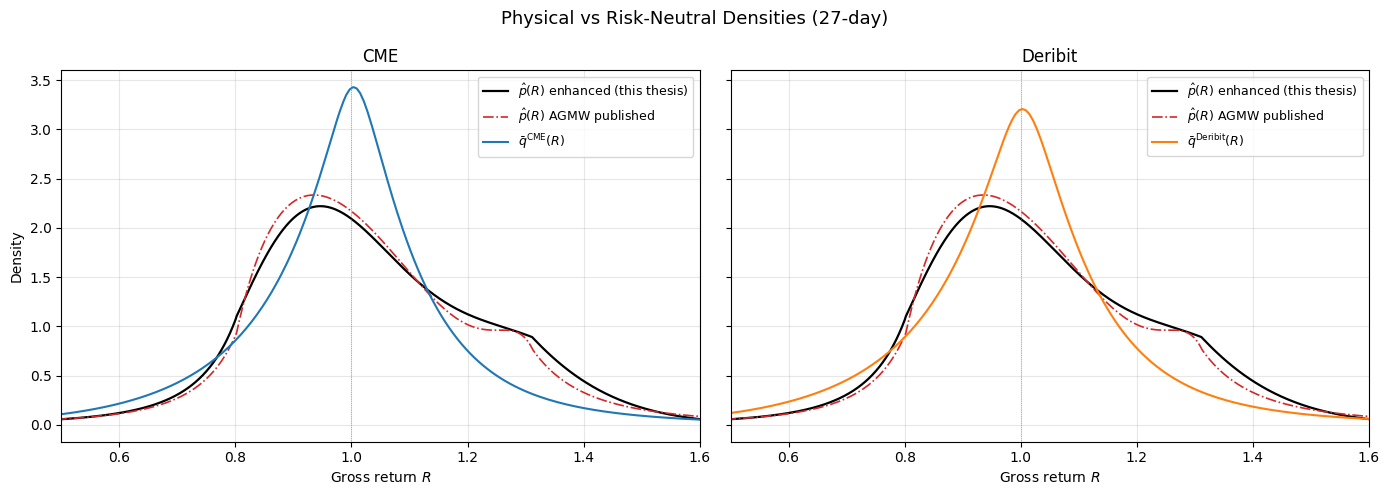

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, q, color) in zip(axes, [('CME', q_cme, 'C0'), ('Deribit', q_der, 'C1')]):
    ax.plot(R, p_enh, 'k-', lw=1.6, label=r'$\hat{p}(R)$ enhanced (this thesis)')
    ax.plot(R, p_van, color='C3', ls='-.', lw=1.2, label=r'$\hat{p}(R)$ AGMW published')
    ax.plot(R, q, color=color, lw=1.5, label=rf'$\bar{{q}}^{{\mathrm{{{venue}}}}}(R)$')
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Density')
fig.suptitle('Physical vs Risk-Neutral Densities (27-day)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_densities_overlay.png', dpi=150)
plt.show()

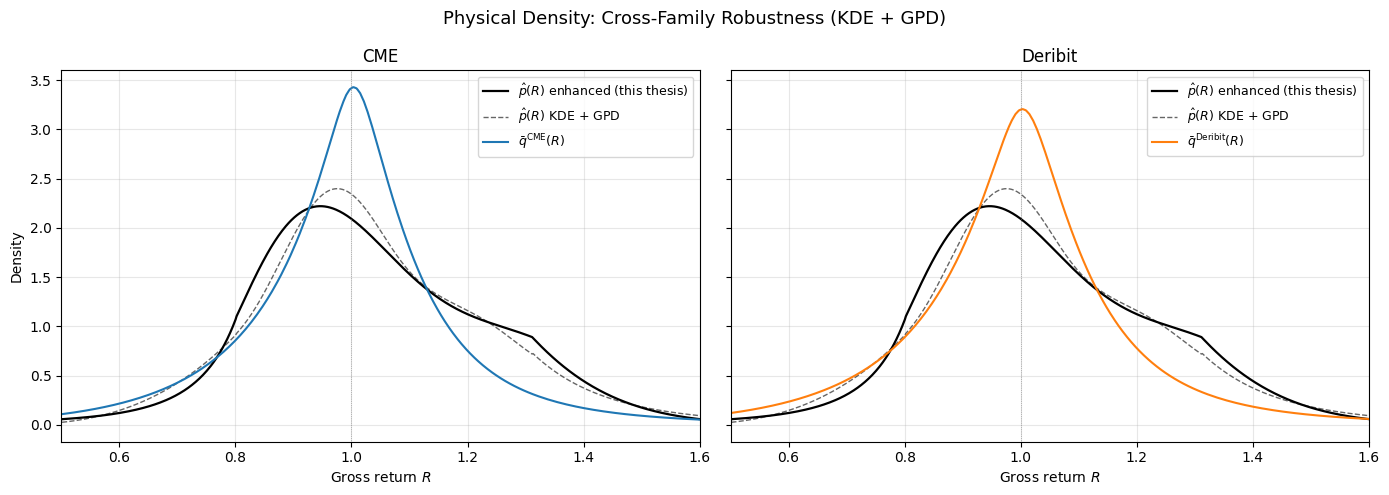

In [13]:
# #### 1b. Appendix — Cross-Family Robustness (KDE + GPD)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, q, color) in zip(axes, [('CME', q_cme, 'C0'), ('Deribit', q_der, 'C1')]):
    ax.plot(R, p_enh, 'k-', lw=1.6, label=r'$\hat{p}(R)$ enhanced (this thesis)')
    ax.plot(R, p_kde, 'k--', lw=1.0, alpha=0.6, label=r'$\hat{p}(R)$ KDE + GPD')
    ax.plot(R, q, color=color, lw=1.5, label=rf'$\bar{{q}}^{{\mathrm{{{venue}}}}}(R)$')
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Density')
fig.suptitle('Physical Density: Cross-Family Robustness (KDE + GPD)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_densities_kde_appendix.png', dpi=150)
plt.show()

#### 2. EP Curve: CME vs Deribit

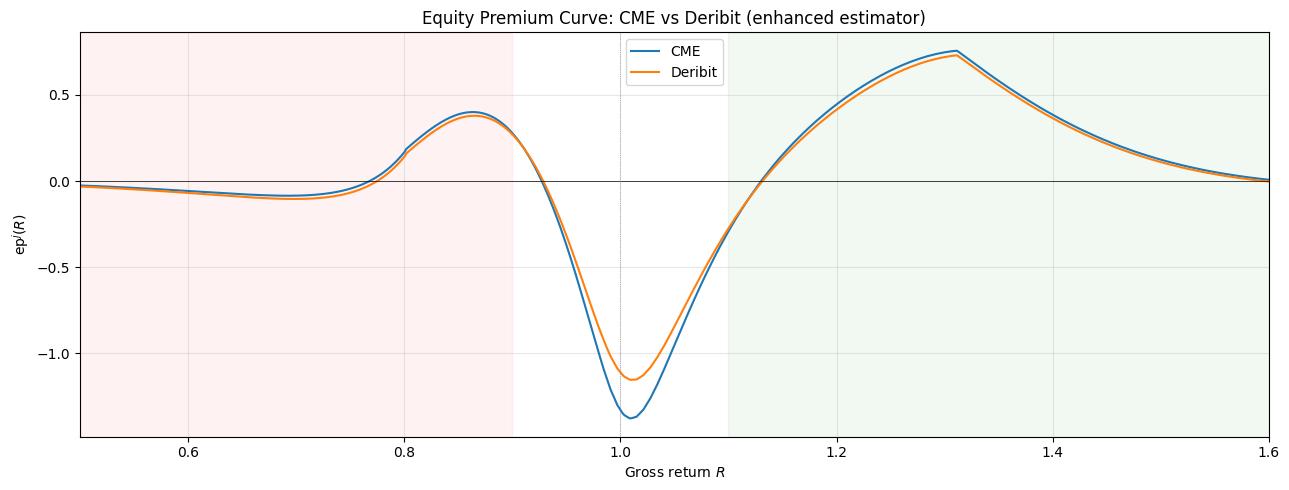

In [14]:
ep_cme = (p_enh - q_cme) * R
ep_der = (p_enh - q_der) * R

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, ep_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, ep_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.axvspan(R[0], 0.90, alpha=0.05, color='red')
ax.axvspan(1.10, R[-1], alpha=0.05, color='green')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\mathrm{ep}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_title('Equity Premium Curve: CME vs Deribit (enhanced estimator)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ep_curve.png', dpi=150)
plt.show()

#### 3. Cumulative EP

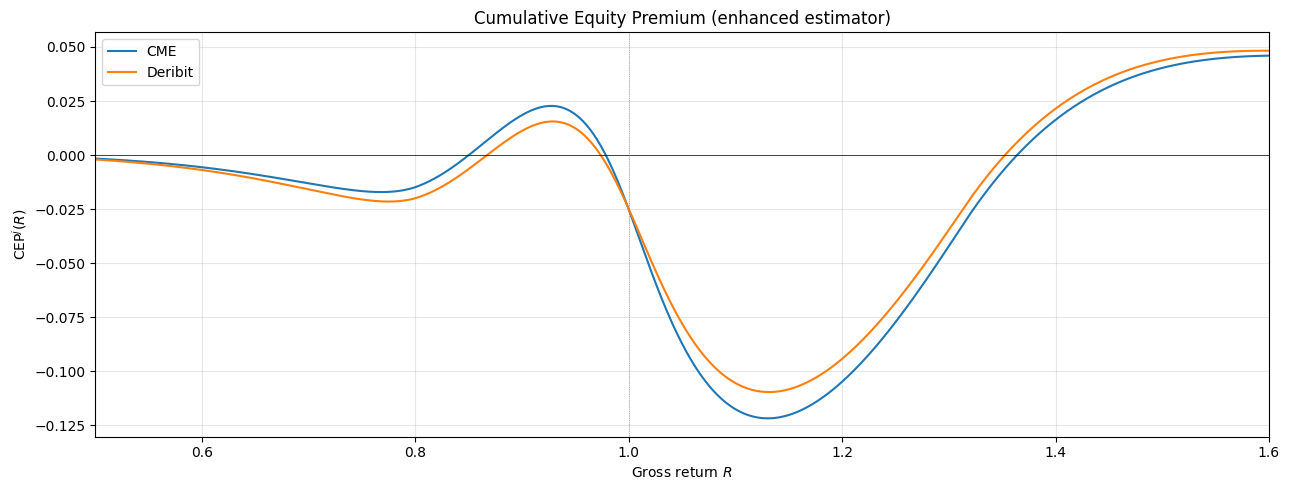

In [15]:
from scipy.integrate import cumulative_trapezoid

cep_cme = cumulative_trapezoid(ep_cme, R, initial=0.0)
cep_der = cumulative_trapezoid(ep_der, R, initial=0.0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, cep_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, cep_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\mathrm{CEP}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_title('Cumulative Equity Premium (enhanced estimator)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_cep_curve.png', dpi=150)
plt.show()

#### 4. Unconditional Pricing Kernel

Under standard risk aversion this should be monotonically decreasing. A hump (local increase) in the small-negative-return region
is the anomaly documented by Almeida et al. (2026) on Deribit.

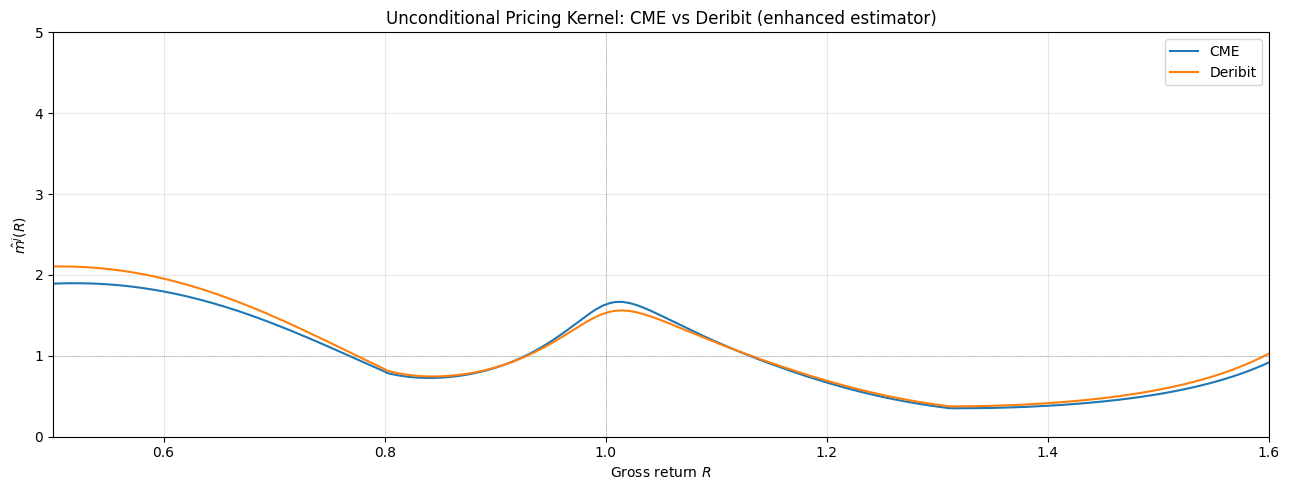

In [16]:
p_safe = np.maximum(p_enh, 1e-15)
k_cme = q_cme / p_safe
k_der = q_der / p_safe
k_cme[p_enh < 1e-15] = np.nan
k_der[p_enh < 1e-15] = np.nan

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, k_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, k_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\hat{m}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_ylim(0, 5)
ax.set_title('Unconditional Pricing Kernel: CME vs Deribit (enhanced estimator)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_kernel_unconditional.png', dpi=150)
plt.show()

#### 5. Regional Decomposition Summary

Decompose total EP into downside ($R < 0.90$), mid ($0.90 \leq R \leq 1.10$), and
upside ($R > 1.10$) contributions.

In [17]:
summary_pp = summary.copy()
for col in ['downside_contrib', 'mid_contrib', 'upside_contrib']:
    summary_pp[col + '_pp'] = summary_pp[col] * 100

pivot_contrib = summary_pp.pivot(
    index='venue', columns='estimator',
    values=['total_ep', 'downside_contrib_pp', 'mid_contrib_pp', 'upside_contrib_pp'])
print("--- Regional contributions (percentage points), reportable ---")
print(pivot_contrib.round(3).to_string())

print("\n--- Regional shares (unstable near-zero denominator; context only) ---")
pivot_share = summary.pivot(
    index='venue', columns='estimator',
    values=['downside_share', 'mid_share', 'upside_share'])
print(pivot_share.round(2).to_string())

--- Regional contributions (percentage points), reportable ---
          total_ep                downside_contrib_pp                mid_contrib_pp                 upside_contrib_pp                
estimator  almeida    kde vanilla             almeida    kde vanilla        almeida     kde vanilla           almeida     kde vanilla
venue                                                                                                                                
CME          0.036  0.042   0.037               1.845  0.164   2.072        -13.636 -11.233 -12.000            15.418  15.253  13.572
DER          0.036  0.042   0.037               1.116 -0.564   1.343        -11.698  -9.296 -10.062            14.208  14.042  12.361

--- Regional shares (unstable near-zero denominator; context only) ---
          downside_share               mid_share               upside_share              
estimator        almeida   kde vanilla   almeida   kde vanilla      almeida   kde vanilla
venue          

#### 6. Estimator Robustness: Almeida vs KDE

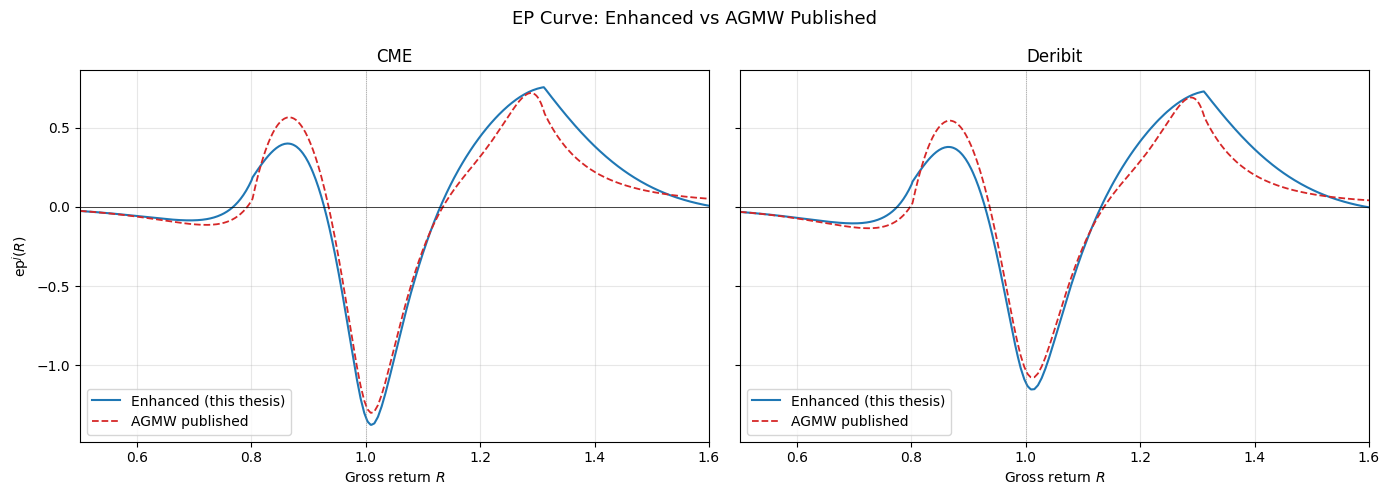

In [18]:
ep_cme_van = (p_van - q_cme) * R
ep_der_van = (p_van - q_der) * R

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, ep_e, ep_v) in zip(axes,
        [('CME', ep_cme, ep_cme_van), ('Deribit', ep_der, ep_der_van)]):
    ax.plot(R, ep_e, 'C0-', lw=1.5, label='Enhanced (this thesis)')
    ax.plot(R, ep_v, 'C3--', lw=1.3, label='AGMW published')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend()
axes[0].set_ylabel(r'$\mathrm{ep}^j(R)$')
fig.suptitle('EP Curve: Enhanced vs AGMW Published', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ep_enhanced_vs_vanilla.png', dpi=150)
plt.show()

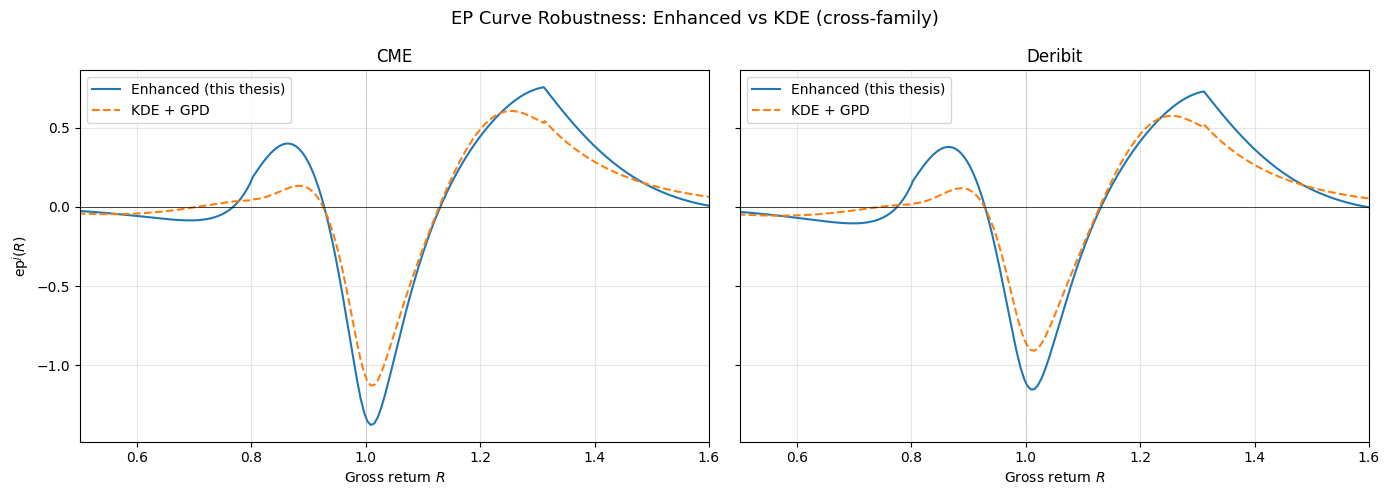

In [19]:
# 6b. Appendix — Estimator Robustness: Enhanced vs KDE

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, ep_e, ep_k) in zip(axes,
        [('CME', ep_cme, (p_kde - q_cme) * R),
         ('Deribit', ep_der, (p_kde - q_der) * R)]):
    ax.plot(R, ep_e, '-', lw=1.5, label='Enhanced (this thesis)')
    ax.plot(R, ep_k, '--', lw=1.5, label='KDE + GPD')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend()
axes[0].set_ylabel(r'$\mathrm{ep}^j(R)$')
fig.suptitle('EP Curve Robustness: Enhanced vs KDE (cross-family)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ep_robustness_kde_appendix.png', dpi=150)
plt.show()

#### 7. Appendix — NB-Sweep Stability and Published-Bound Binding

In [20]:
nb_summary_path = TAB_DIR / 'nb_sweep_summary.csv'
sigma_bind_path = TAB_DIR / 'sigma_binding_check.csv'
nb_fig_path = FIG_DIR / 'fig_nb_sweep_appendix.png'

if nb_summary_path.exists():
    nb_summary = pd.read_csv(nb_summary_path)
    print("--- NB-sweep stability (range as fraction of NB=12 peak) ---")
    print(nb_summary[['estimator', 'venue', 'density_range_pct',
                      'ep_range_pct', 'total_ep_spread']].round(4).to_string(index=False))
else:
    print(f"[not found] {nb_summary_path} — run run_nb_sweep.py first")

if sigma_bind_path.exists():
    bind = pd.read_csv(sigma_bind_path)
    print("\n--- Published-bound binding (vanilla), by NB ---")
    print(bind[['n_bins', 'van_sigma_L', 'van_sigma_R', 'van_any_bound_binds',
               'van_binding_detail', 'van_rank_deficient']].round(4).to_string(index=False))
    n_bind = int(bind['van_any_bound_binds'].sum())
    print(f"\nPublished bounds bind in {n_bind}/{len(bind)} bin-count settings.")
else:
    print(f"[not found] {sigma_bind_path} — run run_nb_sweep.py first")

[not found] C:\Projects\bitcoin-risk-premia\results\phase2\tables\nb_sweep_summary.csv — run run_nb_sweep.py first
[not found] C:\Projects\bitcoin-risk-premia\results\phase2\tables\sigma_binding_check.csv — run run_nb_sweep.py first


In [21]:
from IPython.display import Image, display

if nb_fig_path.exists():
    display(Image(filename=str(nb_fig_path)))
else:
    print(f"[not found] {nb_fig_path} — run run_nb_sweep.py first")

[not found] C:\Projects\bitcoin-risk-premia\results\phase2\figures\fig_nb_sweep_appendix.png — run run_nb_sweep.py first
